1. Начнём с простого - создайте Decision Tree классификатор, используя одноимённый класс из библиотеки sklearn и сохраните его в переменную dt.

﻿У дерева должны быть следующие параметры:
максимальная глубина - 5 уровней
минимальное число образцов в вершине для разделения - 5

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth = 5, min_samples_split = 5)

2.

Скачайте набор данных с тремя переменными: sex, exang, num. Представьте, что при помощи дерева решений мы хотим классифицировать есть или нет у пациента заболевание сердца (переменная num), основываясь на двух признаках: пол (sex) и наличие/отсутсвие стенокардии (exang). Обучите дерево решений на этих данных, используйте entropy в качестве критерия.



Укажите, чему будет равняться значение Information Gain для переменной,  которая будет помещена в корень дерева.

В ответе необходимо указать число с точностью 3 знака после запятой.



In [3]:
df = pd.read_csv('/content/train_data_tree.csv')
df.head()

,sex,exang,num
0,1,1,1
1,1,1,1
2,1,0,1
3,1,0,0
4,1,0,1


In [7]:

X = df[['sex', 'exang']]

y = df[['num']]

clf = DecisionTreeClassifier(criterion = "entropy")

clf.fit(X,y)

# 0 - индекс корня дерева
l_node = clf.tree_.children_left[0] # индекс корня левого поддерева
r_node = clf.tree_.children_right[0] # индекс корня правого поддерева

n1 = clf.tree_.n_node_samples[l_node] # сэмплов в левом поддереве
n2 = clf.tree_.n_node_samples[r_node] # сэмплов в правом поддереве

e1 = clf.tree_.impurity[l_node] # энтропия в корне левого поддерева
e2 = clf.tree_.impurity[r_node] # энтропия в корне правого поддерева

n = clf.tree_.n_node_samples[0] # суммарное кол-во сэмплов
e = clf.tree_.impurity[0] # энтропия корня дерева

average_child_enthropy = (e1*n1/n) + (e2*n2/n)

information_gain = e - average_child_enthropy
round(information_gain, 3)

0.119

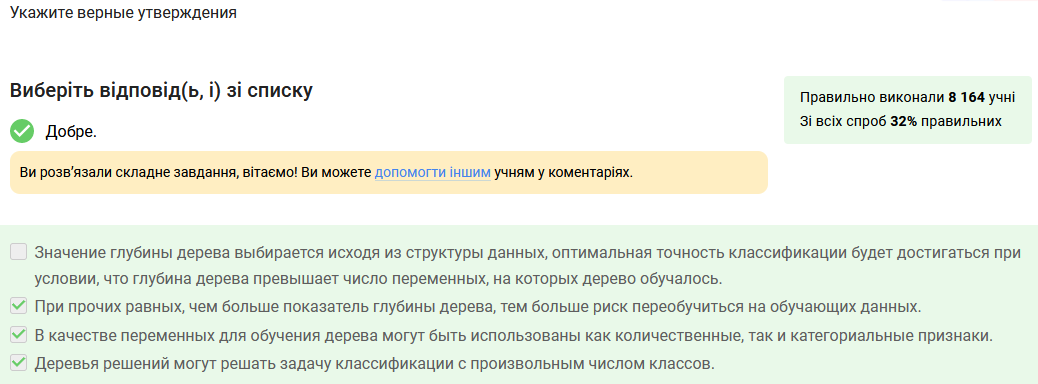

4.

Ярослав наконец-то освоил основы статистики и приступил к машинному обучению, однако, он вновь столкнулся с непреодолимыми трудностями, помогите Ярославу!

Ярослав обучил дерево решений на обучающей выборке и получил 100% точность классификатора, однако на тестовых данных точность классификатора едва превышала 50%, очевидно, что Ярослав пал жертвой переобучения.

Какие действия могут помочь в данной ситуации?


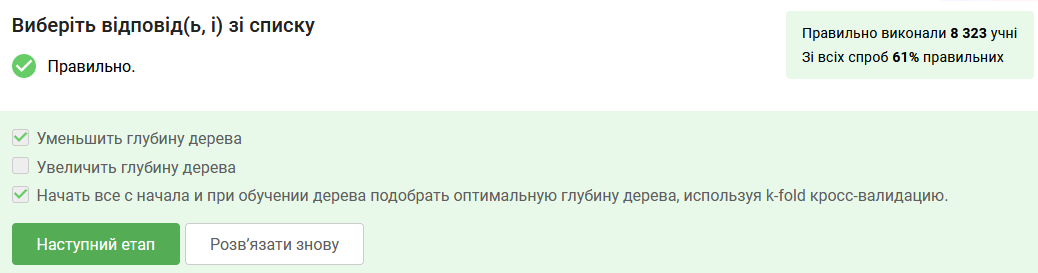

5. Теперь, создав дерево, давайте обучим его и попробуем что-нибудь предсказать!

Для начала опробуем наше дерево на классическом наборе iris, где собраны данные о длине, ширине чашелистиков и лепестков ирисов и их принадлежности к виду. В sklearn он уже встроен, что довольно удобно.

Итак, вам даны 2 numpy эррея с измеренными признаками ирисов и их принадлежностью к виду. Сначала попробуем примитивный способ с разбиением данных на 2 датасэта. Используйте функцию train_test_split для разделения имеющихся данных на тренировочный и тестовый наборы данных, 75% и 25% соответственно.
Затем создайте дерево dt с параметрами по умолчанию и обучите его на тренировочных данных, а после предскажите классы, к которым принадлежат данные из тестовой выборки, сохраните результат предсказаний в переменную predicted.

In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.25)

In [11]:
dt = DecisionTreeClassifier()


In [12]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
predicted = dt.predict(X_test)


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test =  train_test_split(X, y) # В train_test_split по умолчанию стоит разбиение тестовой и тренировочной выборки в пропорции 0.25 и 0.75
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
predicted = dt.predict(X_test)

# other version
#dt = DecisionTreeClassifier(criterion='entropy')
#predicted = dt.fit(X_train,y_train).predict(X_test)

6. Теперь задачка на соотнесение функций sklearn и стратегий разделения датасэта для тестирования.



StratifiedKFold и cross_validate - аналоги, отличаются различием наблюдений в классах

ShuffleSplit и train_test_split - аналоги, отличаются числом случайных разделений

LeavePOut и LeaveOneOut - аналоги, в одном случае берется несколько наблюдений для теста, во втором одно


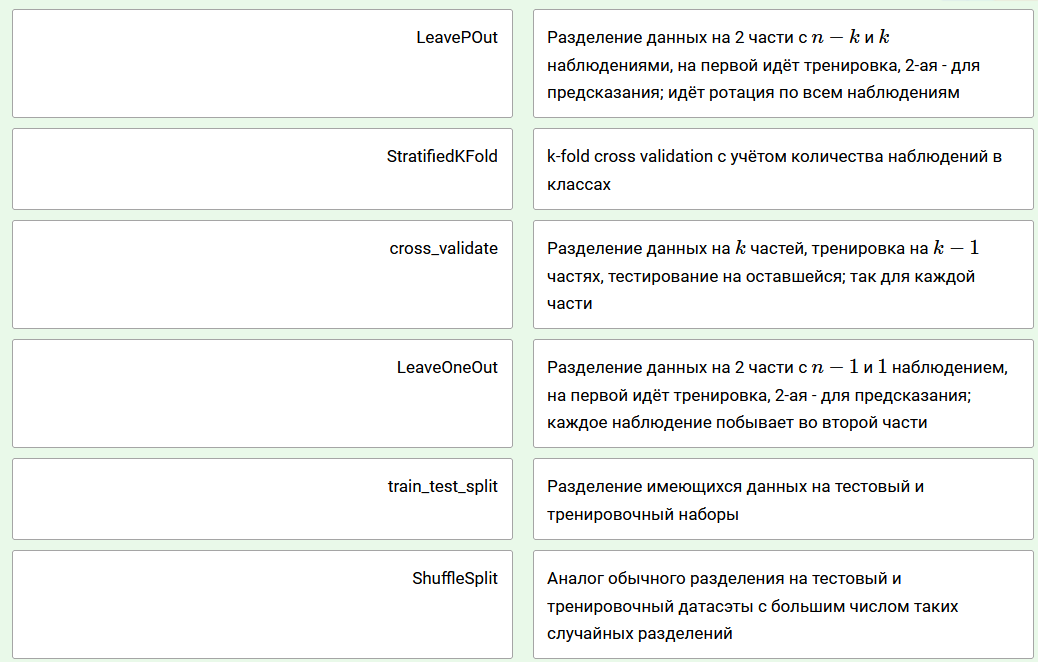

7. В продолжение предыдущего вопроса - расположите разные стратегии разделения данных для кросс-валидации по затратам вычислительных мощностей на последующие предсказания. Сверху самый быстрый и требующий меньше всего вычислений для валидации.

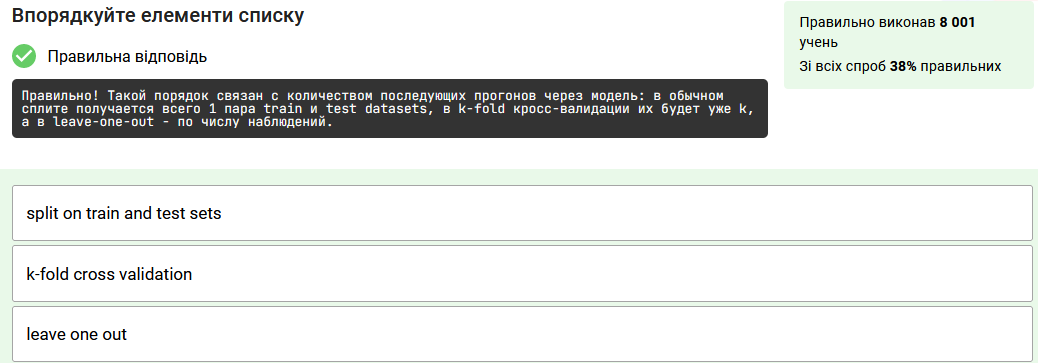

Существуют различные способы вызова кросс-валидации в sklearn, например

cross_val_predict(estimator, x, y, cv=bar)

где estimator - предсказывающая модель, а bar - число блоков при k-fold кросс-валидации или объект из sklearn.model_selection, позволяющий осуществлять кросс-валидацию по другой стратегии.

Мы будем использовать другой способ - GridSearchCV, отбирающий лучшую модель по заданным параметрам, проводя кросс-валидацию.

8. Одно дерево - хорошо, но где гарантии, что оно является лучшим, или хотя бы близко к нему? Одним из способов найти более-менее оптимальный набор параметров дерева является перебор множества деревьев с разными параметрами и выбор подходящего.
Для этой цели существует класс GridSearchCV, перебирающий каждое из сочетаний параметров среди заданных для модели, обучающий её на данных и проводящих кросс-валидацию. После этого в аттрибуте .best_estimator_ храниться модель с лучшими параметрами.
Это применимо не только к деревьям, но и к другим моделям sklearn.

Теперь задание - осуществите перебор всех деревьев на данных ириса по следующим параметрам:

    максимальная глубина - от 1 до 10 уровней
    минимальное число проб для разделения - от 2 до 10
    минимальное число проб в листе - от 1 до 10

и сохраните в переменную best_tree лучшее дерево. Переменную с GridSearchCV назовите search

In [26]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target
dt = DecisionTreeClassifier()

param = {'max_depth' : range(1, 10),
        'min_samples_split': range(2, 10),
        'min_samples_leaf': range(1, 10)}

search = GridSearchCV(dt, param)
search.fit(X, y)
best_tree = search.best_estimator_

In [27]:
print(search.best_score_)
print(search.best_params_)

0.9733333333333334
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 4}


9. Чем больше данных, сложность модели и число её параметров, тем дольше будет вестись поиск GridSearchCV. Однако бывают случаи, когда модель нужна здесь и сейчас, и для этого есть RandomizedSearchCV! Пробегаясь по рандомной подвыборке параметров, он ищет наиболее хорошую модель и делает это быстрее полного перебора параметров, хотя и может пропустить оптимальные параметры.

Здесь можно посмотреть на сравнение этих поисков.

Осуществим поиск по тем же параметрам что и в предыдущем задании с помощью RandomizedSearchCV

    максимальная глубина - от 1 до 10 уровней
    минимальное число проб для разделения - от 2 до 10
    минимальное число проб в листе - от 1 до 10

Cохраните в переменную best_tree лучшее дерево. Переменную с RandomizedSearchCV назовите search

In [28]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target
dt = DecisionTreeClassifier()
param = {'max_depth' : range(1, 10),
        'min_samples_split': range(2, 10),
        'min_samples_leaf': range(1, 10)}

search = RandomizedSearchCV(dt, param)
search.fit(X, y)
best_tree = search.best_estimator_

In [29]:
print(search.best_score_)
print(search.best_params_)

0.9666666666666668
{'min_samples_split': 8, 'min_samples_leaf': 1, 'max_depth': 8}


10.

Воспользуемся изученными приёмами и попредсказываем!

Даны 2 датасэта, к которым вы можете обращаться:

        train - размеченный с известными правильным ответами (хранятся в колонке y)
        test - набор, где нужно предсказать их

Найдите дерево с наиболее подходящими параметрами с помощью GridSearchCV и предскажите с его помощью ответы ко 2-ому сэту! Границы параметров как раньше:

    максимальная глубина - от 1 до 10 уровней
    минимальное число проб для разделения - от 2 до 10
    минимальное число проб в листе - от 1 до 10

Названия переменных тоже:лучшее дерево - best_tree, GridSearchCV - search, а предсказания - predictions


In [34]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

X = train.drop('y', 1)
y = train['y']
dt = DecisionTreeClassifier()

param = {'max_depth' : range(1, 10),
        'min_samples_split': range(2, 10),
        'min_samples_leaf': range(1, 10)}

search = GridSearchCV(dt, param)
search.fit(X, y)
best_tree = search.best_estimator_
predictions = best_tree.predict(test)

NameError: name 'train' is not defined

11. При классификации модель может допускать ошибки, присваивая наблюдению неверный класс. Существуют различные метрики оценки качества предсказаний, которые базируются на 4-ёх параметрах - true positive, false positive, false negative и true negative, соответствующих тому какой класс был присвоен наблюдениям каждого из классов. Матрицу из 4-ёх (в случае бинарной классификации) этих параметров называют confusion matrix.

В sklearn можно её удобно получить с помощью функции confusion_matrix. Вам даны 2 эррея с истинными классами наблюдений и предсказанными - y и predictions. Получите по ним confusion matrix и поместите её в переменную conf_matrix.

In [30]:
import pandas as pd
from sklearn.metrics import confusion_matrix

In [38]:
conf_matrix = confusion_matrix(y, predictions)

In [39]:
conf_matrix

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  0, 50]])

12. Соотнесите описание метрик, которые выводятся из 4-ёх основных параметров, с их названиями.

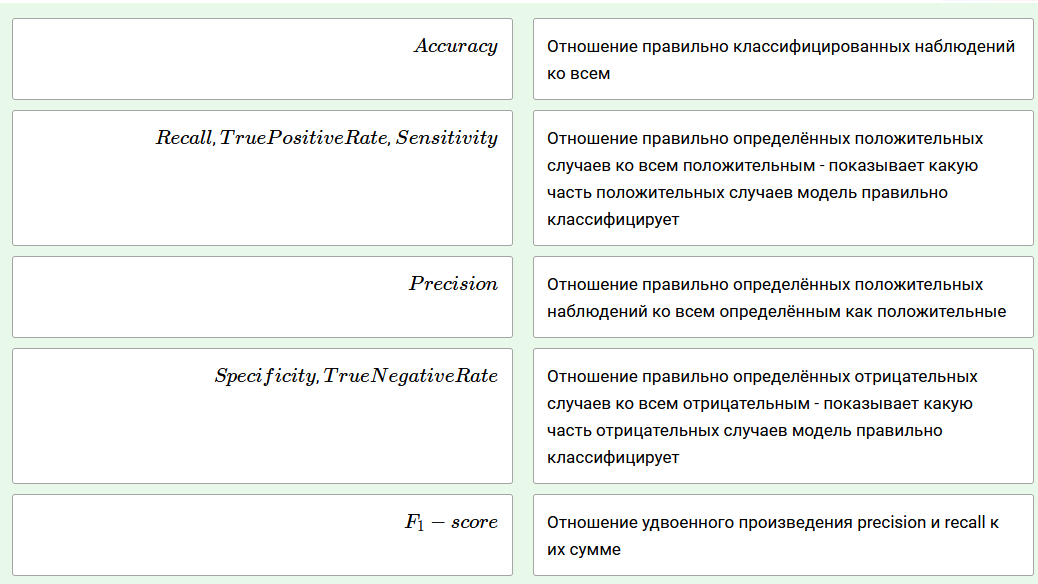